# Attention Mechanisms — PyTorch Pipeline

## Model: Seq2Seq with Attention (EN→ES Translation)
- **Dataset**: Tatoeba EN→ES — 114,478 train / 14,309 val / 14,311 test, 20-token padded sequences
- **Task**: Translate English sentences to Spanish — the problem that invented attention (Bahdanau 2014)
- **Framework showcase**: Progressive attention variants — from bottleneck to multi-head, bridging to Transformers #16

## Evaluation Strategy
- **Primary metric**: BLEU-4 (corpus-level, smoothed) — standard machine translation metric
- **Key experiment**: Per-length BLEU — does attention maintain quality on longer sentences?
- **Visual**: Attention heatmaps showing learned word alignment without explicit supervision

## Pipeline
1. Setup + load data
2. No-Attention baseline (encoder final hidden only — the bottleneck)
3. Bahdanau attention (additive scoring)
4. Luong attention (multiplicative scoring)
5. Multi-head attention (parallel heads — bridge to Transformers)
6. Evaluation & comparison (BLEU, attention heatmaps, sample translations)
7. Per-length BLEU analysis
8. Performance benchmarks
9. Save results

In [1]:
# Step 1: Setup

import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../..'))
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison
from utils.attention_utils import compute_bleu, bleu_by_length
from utils.visualization import (plot_attention_heatmap,
                                  plot_attention_comparison,
                                  plot_bleu_by_length)

FRAMEWORK = 'PyTorch'
RANDOM_STATE = 113
EMBED_DIM = 256
HIDDEN_DIM = 512
BATCH_SIZE = 64
LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
MAX_EPOCHS = 30
PATIENCE = 5
RESULTS_DIR = 'results'

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("[1/9] SETUP")
print("=" * 60)
print(f"  Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# Load preprocessed data
data_dir = '../../data/processed/attention'

src_train = np.load(f'{data_dir}/src_train.npy')
src_val = np.load(f'{data_dir}/src_val.npy')
src_test = np.load(f'{data_dir}/src_test.npy')
tgt_train = np.load(f'{data_dir}/tgt_train.npy')
tgt_val = np.load(f'{data_dir}/tgt_val.npy')
tgt_test = np.load(f'{data_dir}/tgt_test.npy')

with open(f'{data_dir}/src_vocab.json', 'r', encoding='utf-8') as f:
    src_word2idx = json.load(f)
with open(f'{data_dir}/tgt_vocab.json', 'r', encoding='utf-8') as f:
    tgt_word2idx = json.load(f)
with open(f'{data_dir}/src_vocab_inv.json', 'r', encoding='utf-8') as f:
    src_idx2word = json.load(f)
with open(f'{data_dir}/tgt_vocab_inv.json', 'r', encoding='utf-8') as f:
    tgt_idx2word = json.load(f)
with open(f'{data_dir}/preprocessing_info.json', 'r') as f:
    meta = json.load(f)

SRC_VOCAB_SIZE = len(src_word2idx)
TGT_VOCAB_SIZE = len(tgt_word2idx)
MAX_LENGTH = meta['max_length']
PAD_IDX = meta['special_tokens']['<PAD>']
SOS_IDX = meta['special_tokens']['<SOS>']
EOS_IDX = meta['special_tokens']['<EOS>']

print(f"\n  Source vocab: {SRC_VOCAB_SIZE:,} | Target vocab: {TGT_VOCAB_SIZE:,}")
print(f"  Max length: {MAX_LENGTH} | PAD={PAD_IDX} SOS={SOS_IDX} EOS={EOS_IDX}")
print(f"  Train: {src_train.shape[0]:,} | Val: {src_val.shape[0]:,} | Test: {src_test.shape[0]:,}")

# Build DataLoaders
train_dataset = TensorDataset(
    torch.from_numpy(src_train).long(),
    torch.from_numpy(tgt_train).long()
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_src = torch.from_numpy(src_val).long().to(device)
val_tgt = torch.from_numpy(tgt_val).long().to(device)
test_src = torch.from_numpy(src_test).long().to(device)
test_tgt = torch.from_numpy(tgt_test).long().to(device)

print(f"  Train batches: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"\n  Sample EN indices: {src_train[0][:10]}")
print(f"  Sample ES indices: {tgt_train[0][:10]}")

# Helper: decode index sequence back to words (for translation display)
def decode_tokens(indices, idx2word, skip_special=True):
    """Convert index array to word list, stopping at <EOS> or <PAD>."""
    tokens = []
    for idx in indices:
        idx_str = str(int(idx))
        word = idx2word.get(idx_str, '<UNK>')
        if skip_special and word in ('<PAD>', '<SOS>'):
            continue
        if word == '<EOS>':
            break
        tokens.append(word)
    return tokens

# Verify decode works
sample_en = decode_tokens(src_train[0], src_idx2word)
sample_es = decode_tokens(tgt_train[0], tgt_idx2word)
print(f"\n  Decoded sample:")
print(f"    EN: {' '.join(sample_en)}")
print(f"    ES: {' '.join(sample_es)}")

[1/9] SETUP
  Device: cuda
  GPU: NVIDIA GeForce RTX 4090

  Source vocab: 10,004 | Target vocab: 10,004
  Max length: 20 | PAD=0 SOS=1 EOS=2
  Train: 114,478 | Val: 14,309 | Test: 14,311
  Train batches: 1789 (batch_size=64)

  Sample EN indices: [   6  226    8 2441 8215    4    0    0    0    0]
  Sample ES indices: [   1  137 9232    3    4    2    0    0    0    0]

  Decoded sample:
    EN: i used to collect coasters .
    ES: antes coleccionaba <UNK> .


In [2]:
# Step 2: No-Attention Baseline (Seq2Seq)
"""
The classic encoder-decoder: the encoder reads the entire source
sentence and compresses it into a SINGLE fixed-size hidden vector.
The decoder must generate the full translation from only that vector.

This is the "information bottleneck" — as sentences get longer,
more information must be crammed into the same fixed vector.
Attention solves this by letting the decoder look back
at ALL encoder positions, not just the final compressed state.
"""
print("=" * 60)
print("[2/9] NO-ATTENTION BASELINE — THE BOTTLENECK")
print("=" * 60)


class Encoder(nn.Module):
    """
    Bidirectional GRU encoder — shared across all variants.

    Reads the source sentence token by token and produces:
    - outputs: hidden state at EVERY position (used by attention later)
    - hidden: final hidden state (the "bottleneck" for no-attention)

    Bidirectional means we read left-to-right AND right-to-left,
    then combine both directions. This captures context from both
    sides of each word — "bank" means different things depending
    on words before AND after it.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # Bidirectional GRU: outputs are 2*hidden_dim (forward + backward concat)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Project concatenated forward+backward hidden states back to hidden_dim
        # so the decoder (which is unidirectional) gets the right input size
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src):
        # src: (batch, src_len) — integer token indices
        embedded = self.embedding(src)           # (batch, src_len, embed_dim)
        outputs, hidden = self.gru(embedded)     # outputs: (batch, src_len, hidden_dim*2)
                                                 # hidden: (2, batch, hidden_dim) — 2 directions

        # Combine forward and backward final hidden states
        # hidden[0] = forward final, hidden[1] = backward final
        combined = torch.cat([hidden[0], hidden[1]], dim=1)  # (batch, hidden_dim*2)
        hidden = torch.tanh(self.fc_hidden(combined))        # (batch, hidden_dim)
        hidden = hidden.unsqueeze(0)                         # (1, batch, hidden_dim) — GRU expects 3D

        return outputs, hidden


class DecoderNoAttention(nn.Module):
    """
    Decoder WITHOUT attention — uses only the encoder's final hidden state.

    At every decoding step, the decoder sees:
    - The previous token's embedding (ground truth during training, predicted during inference)
    - The encoder's final hidden state (SAME vector at every step = bottleneck!)

    The decoder never looks back at individual source positions.
    For short sentences this works fine. For longer ones, the single
    hidden vector can't encode everything, and quality degrades.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_token, hidden):
        # tgt_token: (batch,) — single token index at current timestep
        # hidden: (1, batch, hidden_dim) — decoder state from previous step
        embedded = self.embedding(tgt_token.unsqueeze(1))    # (batch, 1, embed_dim)
        output, hidden = self.gru(embedded, hidden)          # output: (batch, 1, hidden_dim)
        prediction = self.fc_out(output.squeeze(1))          # (batch, vocab_size)
        return prediction, hidden


class Seq2SeqNoAttention(nn.Module):
    """
    Full encoder-decoder without attention.

    Training uses teacher forcing: with probability TEACHER_FORCING_RATIO,
    we feed the GROUND TRUTH previous token to the decoder instead of its
    own prediction. This stabilizes early training when the model's
    predictions are random garbage.

    Without teacher forcing: model feeds its own (bad) predictions back in,
    errors compound, training diverges.
    With 100% teacher forcing: model never learns to recover from its own
    mistakes ("exposure bias") — performs worse at inference.
    50% is a standard compromise.
    """

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)

        # Store decoder outputs for loss computation
        outputs = torch.zeros(batch_size, tgt_len, TGT_VOCAB_SIZE).to(src.device)

        # Encode source sentence → single hidden vector (the bottleneck)
        _, hidden = self.encoder(src)

        # First decoder input is always <SOS>
        decoder_input = tgt[:, 0]  # (batch,) — <SOS> tokens

        for t in range(1, tgt_len):
            prediction, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t] = prediction

            # Teacher forcing: use ground truth vs model's own prediction
            if np.random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]                    # ground truth
            else:
                decoder_input = prediction.argmax(dim=1)     # model's prediction

        return outputs


def train_seq2seq(model, train_loader, val_src, val_tgt, name,
                  max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """
    Train a seq2seq model with early stopping on validation BLEU.

    Returns training history and best BLEU score.
    """
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # ignore_index=PAD_IDX: don't compute loss on padding tokens
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    best_bleu = 0.0
    patience_counter = 0
    train_losses = []
    val_bleus = []
    best_state = None

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n  {name}")
    print(f"  Parameters: {n_params:,}")
    print(f"  Training (max {max_epochs} epochs, patience={patience})...")

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for src_batch, tgt_batch in train_loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            optimizer.zero_grad()
            output = model(src_batch, tgt_batch, TEACHER_FORCING_RATIO)

            # Reshape for CrossEntropyLoss: (batch*tgt_len, vocab) vs (batch*tgt_len)
            output = output[:, 1:].reshape(-1, TGT_VOCAB_SIZE)
            target = tgt_batch[:, 1:].reshape(-1)

            loss = criterion(output, target)
            loss.backward()
            # Gradient clipping — critical for seq2seq stability
            # Without it, exploding gradients crash training
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validate with BLEU
        val_bleu = evaluate_bleu(model, val_src, val_tgt)
        val_bleus.append(val_bleu)

        if val_bleu > best_bleu:
            best_bleu = val_bleu
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch [{epoch+1:>3}/{max_epochs}] | "
                  f"Loss: {avg_loss:.4f} | Val BLEU: {val_bleu:.4f} | "
                  f"Best: {best_bleu:.4f}")

        if patience_counter >= patience:
            print(f"    Early stop at epoch {epoch+1}")
            break

    # Restore best model
    if best_state:
        model.load_state_dict(best_state)
        model.to(device)

    return {
        'train_losses': train_losses,
        'val_bleus': val_bleus,
        'best_bleu': best_bleu,
        'epochs': len(train_losses),
        'n_params': n_params
    }


def evaluate_bleu(model, src, tgt, batch_size=256):
    # Compute corpus BLEU on a dataset using greedy decoding
    model.eval()
    all_refs = []
    all_hyps = []

    with torch.no_grad():
        for i in range(0, len(src), batch_size):
            src_batch = src[i:i+batch_size]
            tgt_batch = tgt[i:i+batch_size]

            # Greedy decode
            translations = greedy_decode(model, src_batch)

            for j in range(len(src_batch)):
                ref = decode_tokens(tgt_batch[j].cpu().numpy(), tgt_idx2word)
                hyp = decode_tokens(translations[j].cpu().numpy(), tgt_idx2word)
                all_refs.append([ref])   # nltk expects [[ref_tokens]]
                all_hyps.append(hyp)

    return compute_bleu(all_refs, all_hyps)


def greedy_decode(model, src, max_len=MAX_LENGTH):
    """
    Translate source sentences using greedy (argmax) decoding.

    At each step, pick the highest-probability token.
    Simple but effective — beam search would improve quality
    but adds complexity beyond our attention comparison scope.

    Uses *_extra to handle variable return counts across decoder types:
    - DecoderNoAttention: forward(token, hidden) → 2 returns
    - DecoderBahdanau: forward_with_attention(token, hidden, enc_out) → 3 returns
    - DecoderLuong: forward_with_attention(token, hidden, enc_out) → 4 returns
    - DecoderMultiHead: forward_with_attention(token, hidden, enc_out) → 3 returns
    """
    model.eval()
    batch_size = src.size(0)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)

        # Start with <SOS> for entire batch
        decoder_input = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)
        translations = torch.zeros(batch_size, max_len, dtype=torch.long, device=src.device)
        translations[:, 0] = SOS_IDX

        for t in range(1, max_len):
            if hasattr(model.decoder, 'forward_with_attention'):
                # *_extra catches variable return counts (Luong returns 4, others 3)
                prediction, hidden, *_extra = model.decoder.forward_with_attention(
                    decoder_input, hidden, encoder_outputs)
            else:
                prediction, hidden = model.decoder(decoder_input, hidden)

            top1 = prediction.argmax(dim=1)
            translations[:, t] = top1
            decoder_input = top1

    return translations


# Build and train no-attention baseline
encoder = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder_no_attn = DecoderNoAttention(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
model_no_attn = Seq2SeqNoAttention(encoder, decoder_no_attn).to(device)

with track_performance(gpu=True) as perf_no_attn:
    hist_no_attn = train_seq2seq(model_no_attn, train_loader, val_src, val_tgt,
                                  name="Seq2Seq (No Attention)")
    torch.cuda.synchronize()

print(f"\n  Training time: {perf_no_attn['time']:.1f}s")
print(f"  GPU memory: {perf_no_attn['gpu_memory']:.1f} MB")

# Show sample translations
print(f"\n  Sample translations (no attention):")
print(f"  {'-'*50}")
sample_indices = [0, 100, 500, 1000, 5000]
sample_src = test_src[sample_indices]
sample_translations = greedy_decode(model_no_attn, sample_src)

for i, idx in enumerate(sample_indices):
    en = decode_tokens(test_src[idx].cpu().numpy(), src_idx2word)
    ref = decode_tokens(test_tgt[idx].cpu().numpy(), tgt_idx2word)
    hyp = decode_tokens(sample_translations[i].cpu().numpy(), tgt_idx2word)
    print(f"    EN:  {' '.join(en)}")
    print(f"    REF: {' '.join(ref)}")
    print(f"    HYP: {' '.join(hyp)}\n")

[2/9] NO-ATTENTION BASELINE — THE BOTTLENECK

  Seq2Seq (No Attention)
  Parameters: 14,327,060
  Training (max 30 epochs, patience=5)...
    Epoch [  1/30] | Loss: 3.5549 | Val BLEU: 0.1647 | Best: 0.1647
    Epoch [  5/30] | Loss: 1.2316 | Val BLEU: 0.2930 | Best: 0.2930
    Epoch [ 10/30] | Loss: 0.8760 | Val BLEU: 0.2929 | Best: 0.2942
    Early stop at epoch 13

  Training time: 635.6s
  GPU memory: 475.1 MB

  Sample translations (no attention):
  --------------------------------------------------
    EN:  everyone who knew him admired him .
    REF: todos los que le conocían le <UNK> .
    HYP: todos lo <UNK> que él .

    EN:  i know all that .
    REF: yo sé todo eso .
    HYP: sé todo eso .

    EN:  my girlfriend was crying .
    REF: mi novia estaba llorando .
    HYP: mi novia estaba furiosa .

    EN:  he won a bronze medal .
    REF: él ganó una medalla de <UNK> .
    HYP: él ganó una medalla de <UNK> .

    EN:  tom didn ' t stop talking to mary all night .
    REF: tom

[3/9] BAHDANAU (ADDITIVE) ATTENTION

  Seq2Seq + Bahdanau Attention
  Parameters: 16,686,868
  Training (max 30 epochs, patience=5)...
    Epoch [  1/30] | Loss: 3.0280 | Val BLEU: 0.2959 | Best: 0.2959
    Epoch [  5/30] | Loss: 1.0653 | Val BLEU: 0.3810 | Best: 0.3810
    Epoch [ 10/30] | Loss: 0.7542 | Val BLEU: 0.3804 | Best: 0.3836
    Early stop at epoch 13

  Training time: 874.2s
  GPU memory: 874.1 MB

  Sample translations (Bahdanau):
  --------------------------------------------------
    EN:  everyone who knew him admired him .
    REF: todos los que le conocían le <UNK> .
    HYP: todos el lo lo <UNK> .

    EN:  i know all that .
    REF: yo sé todo eso .
    HYP: lo sé eso .

    EN:  my girlfriend was crying .
    REF: mi novia estaba llorando .
    HYP: mi novia estaba llorando .

    EN:  he won a bronze medal .
    REF: él ganó una medalla de <UNK> .
    HYP: él ganó una medalla de <UNK> .

    EN:  tom didn ' t stop talking to mary all night .
    REF: tom no dejó 

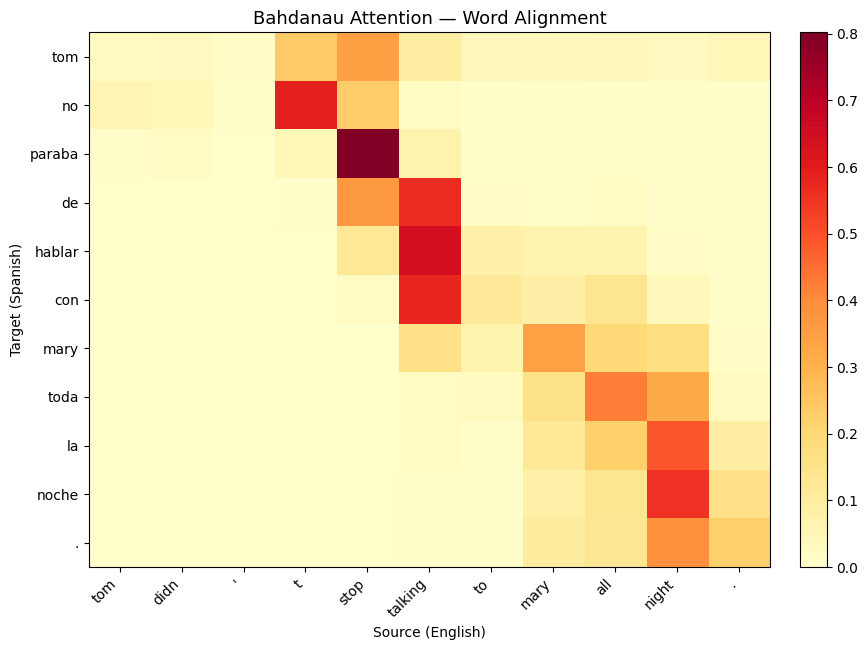

In [3]:
# Step 3: Bahdanau (Additive) Attention
"""
The original attention mechanism (Bahdanau et al., 2014).
Instead of compressing the entire source into one vector,
the decoder can now LOOK BACK at every encoder position.

At each decoder step:
  1. Score every encoder position: how relevant is position i
     to what we're currently trying to generate?
  2. Softmax the scores → attention weights (sum to 1.0)
  3. Weighted sum of encoder outputs → context vector
  4. Feed context + embedding into the decoder GRU

Scoring function (additive/concat):
  score_i = V · tanh(W1·s_{t-1} + W2·h_i)
  - s_{t-1}: decoder hidden state (what we've generated so far)
  - h_i: encoder output at position i (what's at that source position)
  - W1, W2, V: learned parameters

Why "additive"? The score combines decoder and encoder states
by ADDING them (after linear projection), then passing through tanh.
Luong will use MULTIPLICATION instead — simpler but different.

Key difference from no-attention: context is computed BEFORE the
decoder GRU step. The GRU sees [embedding; context] as input.
"""
print("=" * 60)
print("[3/9] BAHDANAU (ADDITIVE) ATTENTION")
print("=" * 60)


class BahdanauAttention(nn.Module):
    """
    Bahdanau additive attention scoring.

    Computes alignment scores between decoder state and all encoder outputs.
    The learned parameters W1, W2, V discover which source positions
    are relevant for each decoder step — no manual alignment needed.
    """

    def __init__(self, hidden_dim):
        super().__init__()
        # W1 projects decoder hidden state, W2 projects encoder outputs
        # V collapses the tanh output to a single score per position
        self.W1 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)
        self.V = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, hidden_dim) — current decoder state
        # encoder_outputs: (batch, src_len, hidden_dim*2) — all encoder positions

        # Expand decoder hidden to match encoder sequence length
        # (batch, hidden_dim) → (batch, 1, hidden_dim) → broadcasts to (batch, src_len, hidden_dim)
        query = self.W1(decoder_hidden).unsqueeze(1)

        # Project encoder outputs: (batch, src_len, hidden_dim*2) → (batch, src_len, hidden_dim)
        keys = self.W2(encoder_outputs)

        # Additive scoring: tanh(W1·s + W2·h) then V to scalar
        energy = torch.tanh(query + keys)              # (batch, src_len, hidden_dim)
        scores = self.V(energy).squeeze(-1)            # (batch, src_len)

        # Softmax → attention weights (each position gets a weight, sum to 1)
        attn_weights = torch.softmax(scores, dim=1)    # (batch, src_len)

        # Weighted sum of encoder outputs → context vector
        # (batch, 1, src_len) @ (batch, src_len, hidden*2) → (batch, 1, hidden*2)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1)                   # (batch, hidden_dim*2)

        return context, attn_weights


class DecoderBahdanau(nn.Module):
    """
    Decoder with Bahdanau attention.

    Unlike no-attention decoder, this one computes a context vector
    at each step by attending to encoder outputs. The GRU input is
    [embedding; context] — so the decoder knows WHAT to focus on
    in the source sentence for each target word it generates.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hidden_dim)
        # GRU input: embedding + context (context is hidden_dim*2 from bidirectional encoder)
        self.gru = nn.GRU(embed_dim + hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token: (batch,) — single token at current step
        # hidden: (1, batch, hidden_dim) — previous decoder state
        # encoder_outputs: (batch, src_len, hidden_dim*2) — all encoder positions

        embedded = self.embedding(tgt_token)             # (batch, embed_dim)

        # Compute attention context using previous hidden state
        context, attn_weights = self.attention(
            hidden.squeeze(0), encoder_outputs)          # context: (batch, hidden_dim*2)

        # Concatenate embedding + context as GRU input
        gru_input = torch.cat([embedded, context], dim=1)  # (batch, embed_dim + hidden*2)
        gru_input = gru_input.unsqueeze(1)                 # (batch, 1, embed_dim + hidden*2)

        output, hidden = self.gru(gru_input, hidden)       # output: (batch, 1, hidden_dim)
        prediction = self.fc_out(output.squeeze(1))        # (batch, vocab_size)

        return prediction, hidden, attn_weights

    def forward_with_attention(self, tgt_token, hidden, encoder_outputs):
        """Alias for greedy_decode compatibility."""
        return self.forward(tgt_token, hidden, encoder_outputs)


class Seq2SeqBahdanau(nn.Module):
    """Seq2seq with Bahdanau attention — encoder outputs now used at every step."""

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        outputs = torch.zeros(batch_size, tgt_len, TGT_VOCAB_SIZE).to(src.device)

        # Encoder now returns BOTH outputs (all positions) and hidden
        encoder_outputs, hidden = self.encoder(src)

        decoder_input = tgt[:, 0]

        for t in range(1, tgt_len):
            # Key difference: decoder receives encoder_outputs at every step
            prediction, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t] = prediction

            if np.random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]
            else:
                decoder_input = prediction.argmax(dim=1)

        return outputs


# Build and train Bahdanau model
# Reuse the SAME encoder architecture (new instance with fresh weights)
encoder_bah = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder_bah = DecoderBahdanau(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
model_bahdanau = Seq2SeqBahdanau(encoder_bah, decoder_bah).to(device)

with track_performance(gpu=True) as perf_bahdanau:
    hist_bahdanau = train_seq2seq(model_bahdanau, train_loader, val_src, val_tgt,
                                   name="Seq2Seq + Bahdanau Attention")
    torch.cuda.synchronize()

print(f"\n  Training time: {perf_bahdanau['time']:.1f}s")
print(f"  GPU memory: {perf_bahdanau['gpu_memory']:.1f} MB")

# Show sample translations + attention heatmap
print(f"\n  Sample translations (Bahdanau):")
print(f"  {'-'*50}")
sample_translations_bah = greedy_decode(model_bahdanau, sample_src)

for i, idx in enumerate(sample_indices):
    en = decode_tokens(test_src[idx].cpu().numpy(), src_idx2word)
    ref = decode_tokens(test_tgt[idx].cpu().numpy(), tgt_idx2word)
    hyp = decode_tokens(sample_translations_bah[i].cpu().numpy(), tgt_idx2word)
    print(f"    EN:  {' '.join(en)}")
    print(f"    REF: {' '.join(ref)}")
    print(f"    HYP: {' '.join(hyp)}\n")

# Attention heatmap for one sentence — the signature visualization
# Pick a medium-length sentence for a clear, readable heatmap
model_bahdanau.eval()
with torch.no_grad():
    heatmap_src = test_src[sample_indices[4]].unsqueeze(0)  # longest sample
    enc_out, hidden = model_bahdanau.encoder(heatmap_src)
    decoder_input = torch.tensor([SOS_IDX], device=device)

    attn_matrix = []
    hyp_tokens_viz = []

    for t in range(1, MAX_LENGTH):
        pred, hidden, attn_w = model_bahdanau.decoder(decoder_input, hidden, enc_out)
        attn_matrix.append(attn_w.squeeze(0).cpu().numpy())
        top1 = pred.argmax(dim=1)

        word = tgt_idx2word.get(str(top1.item()), '<UNK>')
        if word == '<EOS>':
            break
        hyp_tokens_viz.append(word)
        decoder_input = top1

src_tokens_viz = decode_tokens(test_src[sample_indices[4]].cpu().numpy(), src_idx2word)
attn_matrix = np.array(attn_matrix)[:, :len(src_tokens_viz)]

plot_attention_heatmap(attn_matrix, src_tokens_viz, hyp_tokens_viz,
                       title='Bahdanau Attention — Word Alignment',
                       save_path='results/bahdanau_attention_heatmap.png')

In [4]:
# Step 4: Luong (Multiplicative) Attention
"""
Luong et al. (2015) simplified Bahdanau's scoring function.
Instead of additive scoring (W1·s + W2·h → tanh → V),
Luong uses a direct multiplication:

  General:     score = s^T · W · h     (learned bilinear form)
  Dot-product: score = s^T · h         (no learned parameters!)

The other key difference: Luong computes attention AFTER the
decoder GRU step (vs Bahdanau's BEFORE). The decoder first
updates its state, THEN decides where to look in the source.

We implement the "general" form (with learned W matrix) —
the dot-product form requires decoder and encoder to have the
same dimension, which our bidirectional encoder doesn't satisfy.

Two corrections from the Luong paper that matter:

1. Eq. 5 (attentional hidden state): Instead of fc_out(concat(s, c)),
   compress with h̃ = tanh(W_c · [s; c]) THEN predict from h̃.
   Without this, the output layer does both fusion AND projection —
   too much work for one matrix.

2. Section 3.3 (input feeding): Feed h̃_{t-1} back as extra GRU input,
   so each attention step knows what was attended to previously.
   The GRU input becomes [embedding; h̃_{t-1}] instead of just [embedding].
   Paper ablation shows +1.0-1.3 BLEU from this alone.

The dot-product variant (s^T · h) is what transformers use —
it's the simplest possible attention and scales to multi-head
in Cell 5 with just Q·K^T/√d_k.
"""
print("=" * 60)
print("[4/9] LUONG (MULTIPLICATIVE) ATTENTION")
print("=" * 60)


class LuongAttention(nn.Module):
    # Luong general attention: score = s^T · W · h

    def __init__(self, hidden_dim, encoder_dim):
        super().__init__()
        self.W = nn.Linear(encoder_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        keys = self.W(encoder_outputs)
        scores = torch.bmm(decoder_hidden.unsqueeze(1),
                           keys.transpose(1, 2)).squeeze(1)
        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1),
                            encoder_outputs).squeeze(1)
        return context, attn_weights


class DecoderLuong(nn.Module):
    """
    Decoder with Luong attention — Eq. 5 (tanh W_c) + input feeding (Section 3.3).

    Input feeding: the attentional hidden state h̃ from the previous step
    is concatenated with the current embedding as GRU input. This gives
    the model memory of previous attention decisions — equivalent to what
    Bahdanau gets implicitly by feeding context into its GRU.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        # Input feeding: GRU receives [embedding ; h_tilde_{t-1}]
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.attention = LuongAttention(hidden_dim, encoder_dim)
        # Eq. 5: compress [hidden; context] → hidden_dim with tanh
        self.W_c = nn.Linear(hidden_dim + encoder_dim, hidden_dim, bias=False)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_token, hidden, encoder_outputs, h_tilde_prev):
        # h_tilde_prev: (batch, hidden_dim) — attentional state from last step
        embedded = self.embedding(tgt_token)                       # (batch, embed_dim)

        # Input feeding: concatenate embedding with previous attentional state
        gru_input = torch.cat([embedded, h_tilde_prev], dim=1)     # (batch, embed_dim + hidden_dim)
        gru_input = gru_input.unsqueeze(1)                         # (batch, 1, embed_dim + hidden_dim)

        output, hidden = self.gru(gru_input, hidden)
        decoder_state = output.squeeze(1)                          # (batch, hidden_dim)

        context, attn_weights = self.attention(decoder_state, encoder_outputs)

        # Attentional hidden state (Eq. 5)
        combined = torch.cat([decoder_state, context], dim=1)
        h_tilde = torch.tanh(self.W_c(combined))                  # (batch, hidden_dim)
        prediction = self.fc_out(h_tilde)                          # (batch, vocab_size)

        return prediction, hidden, attn_weights, h_tilde

    def forward_with_attention(self, tgt_token, hidden, encoder_outputs, h_tilde_prev=None):
        """Compatibility wrapper — auto-initializes h_tilde if not provided."""
        if h_tilde_prev is None:
            batch_size = tgt_token.size(0)
            h_tilde_prev = torch.zeros(batch_size, self.hidden_dim, device=tgt_token.device)
        return self.forward(tgt_token, hidden, encoder_outputs, h_tilde_prev)


class Seq2SeqLuong(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        outputs = torch.zeros(batch_size, tgt_len, TGT_VOCAB_SIZE).to(src.device)

        encoder_outputs, hidden = self.encoder(src)
        decoder_input = tgt[:, 0]

        # Initialize h_tilde to zeros for the first step (no previous attention)
        h_tilde = torch.zeros(batch_size, self.decoder.hidden_dim, device=src.device)

        for t in range(1, tgt_len):
            prediction, hidden, _, h_tilde = self.decoder(
                decoder_input, hidden, encoder_outputs, h_tilde)
            outputs[:, t] = prediction

            if np.random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]
            else:
                decoder_input = prediction.argmax(dim=1)

        return outputs

# Build and train Luong model
encoder_dim = HIDDEN_DIM * 2
encoder_lu = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder_lu = DecoderLuong(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, encoder_dim)
model_luong = Seq2SeqLuong(encoder_lu, decoder_lu).to(device)

with track_performance(gpu=True) as perf_luong:
    hist_luong = train_seq2seq(model_luong, train_loader, val_src, val_tgt,
                                name="Seq2Seq + Luong Attention (General) — w/ Input Feeding")
    torch.cuda.synchronize()

print(f"\n  Training time: {perf_luong['time']:.1f}s")
print(f"  GPU memory: {perf_luong['gpu_memory']:.1f} MB")

# Show sample translations
print(f"\n  Sample translations (Luong):")
print(f"  {'-'*50}")
sample_translations_lu = greedy_decode(model_luong, sample_src)

for i, idx in enumerate(sample_indices):
    en = decode_tokens(test_src[idx].cpu().numpy(), src_idx2word)
    ref = decode_tokens(test_tgt[idx].cpu().numpy(), tgt_idx2word)
    hyp = decode_tokens(sample_translations_lu[i].cpu().numpy(), tgt_idx2word)
    print(f"    EN:  {' '.join(en)}")
    print(f"    REF: {' '.join(ref)}")
    print(f"    HYP: {' '.join(hyp)}\n")

[4/9] LUONG (MULTIPLICATIVE) ATTENTION

  Seq2Seq + Luong Attention (General) — w/ Input Feeding
  Parameters: 16,424,212
  Training (max 30 epochs, patience=5)...
    Epoch [  1/30] | Loss: 3.4635 | Val BLEU: 0.1362 | Best: 0.1362
    Epoch [  5/30] | Loss: 1.4871 | Val BLEU: 0.1991 | Best: 0.2000
    Epoch [ 10/30] | Loss: 1.2605 | Val BLEU: 0.2023 | Best: 0.2031
    Early stop at epoch 11

  Training time: 720.8s
  GPU memory: 1015.1 MB

  Sample translations (Luong):
  --------------------------------------------------
    EN:  everyone who knew him admired him .
    REF: todos los que le conocían le <UNK> .
    HYP: todo el mundo que lo que lo <UNK> le <UNK> .

    EN:  i know all that .
    REF: yo sé todo eso .
    HYP: lo sé todo eso .

    EN:  my girlfriend was crying .
    REF: mi novia estaba llorando .
    HYP: mi me mi estaba llorando .

    EN:  he won a bronze medal .
    REF: él ganó una medalla de <UNK> .
    HYP: él ganó una medalla de <UNK> .

    EN:  tom didn ' t 

In [5]:
# Step 5: Multi-Head Attention
"""
Multi-head attention (Vaswani et al., 2017) — the core mechanism of
Transformers, but here still wrapped inside our RNN encoder-decoder.

Instead of computing a SINGLE attention distribution over the source,
we split the representation into multiple "heads" that attend independently:

  For each head k:
    Q_k = W_Q^k · decoder_state     (what am I looking for?)
    K_k = W_K^k · encoder_outputs   (what does each position offer?)
    V_k = W_V^k · encoder_outputs   (what information to extract?)
    head_k = softmax(Q_k · K_k^T / √d_k) · V_k

  output = W_O · concat(head_1, ..., head_n)

Why multiple heads? Each head can learn different attention patterns:
- Head 1 might align subject→subject
- Head 2 might track adjective→noun agreement
- Head 3 might handle word reordering (English SVO → Spanish flexible order)

The √d_k scaling prevents dot products from growing large with dimension,
which would push softmax into saturation (all weight on one position).

This IS the transformer's attention mechanism. The only difference:
Transformers remove the RNN entirely and use ONLY this attention + position
encoding. That's Model #16 — "what if we dropped the GRU?"
"""
print("=" * 60)
print("[5/9] MULTI-HEAD ATTENTION")
print("=" * 60)


"""
Universal greedy_decode and evaluate_bleu
Replaces the Cell 2 versions to handle ALL decoder types:
- DecoderNoAttention: forward(token, hidden) → 2 returns
- DecoderBahdanau: forward_with_attention(token, hidden, enc_out) → 3 returns
- DecoderLuong: forward_with_attention(token, hidden, enc_out, h_tilde) → 4 returns
- DecoderMultiHead: forward_with_attention(token, hidden, enc_out) → 3 returns
"""
def greedy_decode(model, src, max_len=MAX_LENGTH):
    """
    Universal greedy decoder — handles all 4 seq2seq variants.
    Routes based on decoder type: Luong needs h_tilde tracking,
    others use standard 3-arg forward_with_attention.
    """
    model.eval()
    batch_size = src.size(0)
    is_luong = isinstance(model.decoder, DecoderLuong)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)
        decoder_input = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)
        translations = torch.zeros(batch_size, max_len, dtype=torch.long, device=src.device)
        translations[:, 0] = SOS_IDX

        # Luong tracks h_tilde across steps (input feeding)
        h_tilde = torch.zeros(batch_size, HIDDEN_DIM, device=src.device) if is_luong else None

        for t in range(1, max_len):
            if hasattr(model.decoder, 'forward_with_attention'):
                if is_luong:
                    prediction, hidden, _, h_tilde = model.decoder.forward_with_attention(
                        decoder_input, hidden, encoder_outputs, h_tilde)
                else:
                    prediction, hidden, _ = model.decoder.forward_with_attention(
                        decoder_input, hidden, encoder_outputs)
            else:
                prediction, hidden = model.decoder(decoder_input, hidden)

            top1 = prediction.argmax(dim=1)
            translations[:, t] = top1
            decoder_input = top1

    return translations


def evaluate_bleu(model, src, tgt, batch_size=256):
    # Universal BLEU evaluation — works with all decoder types
    model.eval()
    all_refs = []
    all_hyps = []

    with torch.no_grad():
        for i in range(0, len(src), batch_size):
            src_batch = src[i:i+batch_size]
            tgt_batch = tgt[i:i+batch_size]

            translations = greedy_decode(model, src_batch)

            for j in range(len(src_batch)):
                ref = decode_tokens(tgt_batch[j].cpu().numpy(), tgt_idx2word)
                hyp = decode_tokens(translations[j].cpu().numpy(), tgt_idx2word)
                all_refs.append([ref])
                all_hyps.append(hyp)

    return compute_bleu(all_refs, all_hyps)


# Multi-Head Attention Module

class MultiHeadAttention(nn.Module):
    """
    Scaled dot-product attention with multiple heads.

    Each head operates on a d_k = hidden_dim / n_heads slice.
    Heads attend independently, then concatenate → linear projection.
    """

    def __init__(self, hidden_dim, encoder_dim, n_heads=8):
        super().__init__()
        assert hidden_dim % n_heads == 0, "hidden_dim must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_k = hidden_dim // n_heads  # dimension per head

        # Separate projections for Q (from decoder), K and V (from encoder)
        self.W_Q = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_K = nn.Linear(encoder_dim, hidden_dim, bias=False)
        self.W_V = nn.Linear(encoder_dim, hidden_dim, bias=False)
        self.W_O = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, src_len, encoder_dim)
        batch_size = decoder_hidden.size(0)
        src_len = encoder_outputs.size(1)

        # Project and reshape into (batch, n_heads, seq_len, d_k)
        Q = self.W_Q(decoder_hidden).view(batch_size, 1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(encoder_outputs).view(batch_size, src_len, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(encoder_outputs).view(batch_size, src_len, self.n_heads, self.d_k).transpose(1, 2)
        # Q: (batch, n_heads, 1, d_k), K/V: (batch, n_heads, src_len, d_k)

        # Scaled dot-product: softmax(Q·K^T / √d_k) · V
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        # scores: (batch, n_heads, 1, src_len)
        attn_weights = torch.softmax(scores, dim=-1)

        # Weighted sum of values
        head_output = torch.matmul(attn_weights, V)  # (batch, n_heads, 1, d_k)

        # Concatenate heads and project
        concat = head_output.transpose(1, 2).contiguous().view(batch_size, -1)
        # concat: (batch, hidden_dim) — all heads concatenated
        output = self.W_O(concat)  # (batch, hidden_dim)

        # Average attention weights across heads for visualization
        avg_weights = attn_weights.mean(dim=1).squeeze(1)  # (batch, src_len)

        return output, avg_weights

class DecoderMultiHead(nn.Module):
    """
    Decoder with multi-head attention.

    Computes attention AFTER the GRU step (like Luong), but uses
    multi-head scaled dot-product instead of single-head bilinear scoring.
    Uses Eq. 5 tanh compression (W_c) for consistency.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim, n_heads=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.attention = MultiHeadAttention(hidden_dim, encoder_dim, n_heads)
        # Eq. 5 pattern: compress [decoder_state; context] → hidden_dim
        self.W_c = nn.Linear(hidden_dim + hidden_dim, hidden_dim, bias=False)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_token, hidden, encoder_outputs):
        embedded = self.embedding(tgt_token)                      # (batch, embed_dim)
        gru_input = embedded.unsqueeze(1)                         # (batch, 1, embed_dim)

        output, hidden = self.gru(gru_input, hidden)
        decoder_state = output.squeeze(1)                         # (batch, hidden_dim)

        # Multi-head attention over encoder outputs
        context, attn_weights = self.attention(decoder_state, encoder_outputs)
        # context: (batch, hidden_dim) — already projected by W_O

        # Attentional hidden state (same Eq. 5 pattern as Luong)
        combined = torch.cat([decoder_state, context], dim=1)     # (batch, hidden_dim*2)
        h_tilde = torch.tanh(self.W_c(combined))                 # (batch, hidden_dim)
        prediction = self.fc_out(h_tilde)                         # (batch, vocab_size)

        return prediction, hidden, attn_weights

    def forward_with_attention(self, tgt_token, hidden, encoder_outputs):
        """Alias for greedy_decode compatibility."""
        return self.forward(tgt_token, hidden, encoder_outputs)


class Seq2SeqMultiHead(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        outputs = torch.zeros(batch_size, tgt_len, TGT_VOCAB_SIZE).to(src.device)

        encoder_outputs, hidden = self.encoder(src)
        decoder_input = tgt[:, 0]

        for t in range(1, tgt_len):
            prediction, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t] = prediction

            if np.random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]
            else:
                decoder_input = prediction.argmax(dim=1)

        return outputs


N_HEADS = 8
encoder_dim = HIDDEN_DIM * 2
encoder_mh = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
decoder_mh = DecoderMultiHead(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, encoder_dim, N_HEADS)
model_multihead = Seq2SeqMultiHead(encoder_mh, decoder_mh).to(device)

with track_performance(gpu=True) as perf_multihead:
    hist_multihead = train_seq2seq(model_multihead, train_loader, val_src, val_tgt,
                                    name=f"Seq2Seq + Multi-Head Attention ({N_HEADS} heads)")
    torch.cuda.synchronize()

print(f"\n  Training time: {perf_multihead['time']:.1f}s")
print(f"  GPU memory: {perf_multihead['gpu_memory']:.1f} MB")

# Show sample translations
print(f"\n  Sample translations (Multi-Head):")
print(f"  {'-'*50}")
sample_translations_mh = greedy_decode(model_multihead, sample_src)

for i, idx in enumerate(sample_indices):
    en = decode_tokens(test_src[idx].cpu().numpy(), src_idx2word)
    ref = decode_tokens(test_tgt[idx].cpu().numpy(), tgt_idx2word)
    hyp = decode_tokens(sample_translations_mh[i].cpu().numpy(), tgt_idx2word)
    print(f"    EN:  {' '.join(en)}")
    print(f"    REF: {' '.join(ref)}")
    print(f"    HYP: {' '.join(hyp)}\n")

[5/9] MULTI-HEAD ATTENTION

  Seq2Seq + Multi-Head Attention (8 heads)
  Parameters: 16,424,212
  Training (max 30 epochs, patience=5)...
    Epoch [  1/30] | Loss: 3.7345 | Val BLEU: 0.1584 | Best: 0.1584
    Epoch [  5/30] | Loss: 1.4210 | Val BLEU: 0.2935 | Best: 0.2935
    Epoch [ 10/30] | Loss: 1.0694 | Val BLEU: 0.3029 | Best: 0.3029
    Epoch [ 15/30] | Loss: 1.0018 | Val BLEU: 0.2948 | Best: 0.3029
    Early stop at epoch 15

  Training time: 1208.9s
  GPU memory: 1295.2 MB

  Sample translations (Multi-Head):
  --------------------------------------------------
    EN:  everyone who knew him admired him .
    REF: todos los que le conocían le <UNK> .
    HYP: todos sabían que lo cual .

    EN:  i know all that .
    REF: yo sé todo eso .
    HYP: sé todo todos eso .

    EN:  my girlfriend was crying .
    REF: mi novia estaba llorando .
    HYP: mi novia estaba llorando .

    EN:  he won a bronze medal .
    REF: él ganó una medalla de <UNK> .
    HYP: él ganó una medalla d

[6/9] EVALUATION & COMPARISON

  Computing test BLEU for all variants...
    No Attention    | Test BLEU: 0.2942
    Bahdanau        | Test BLEU: 0.3803
    Luong           | Test BLEU: 0.2866
    Multi-Head      | Test BLEU: 0.2993

  Best: Bahdanau (0.3803)


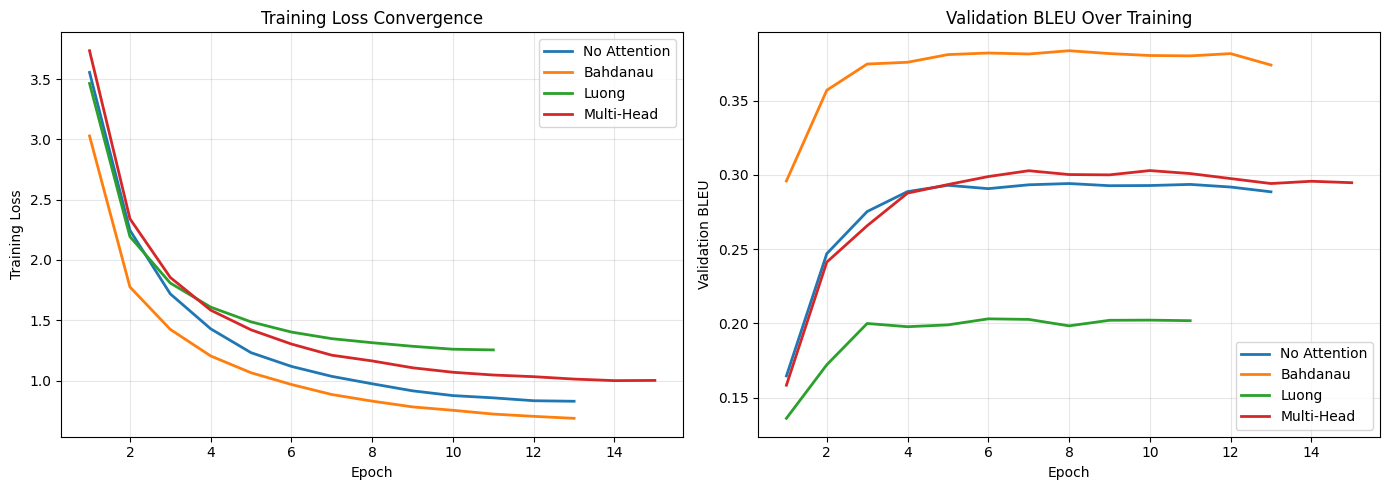

  Saved: results/training_curves.png


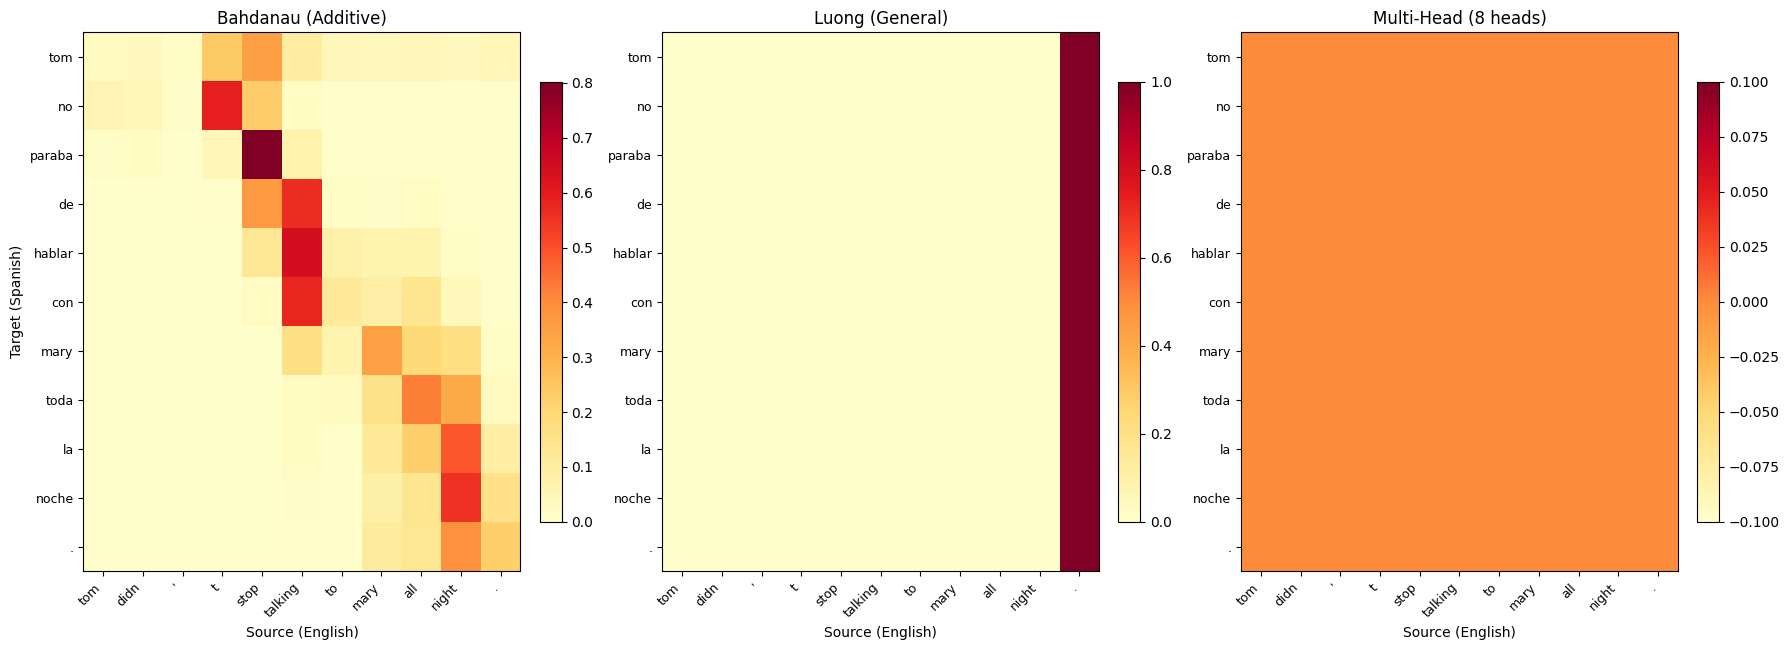

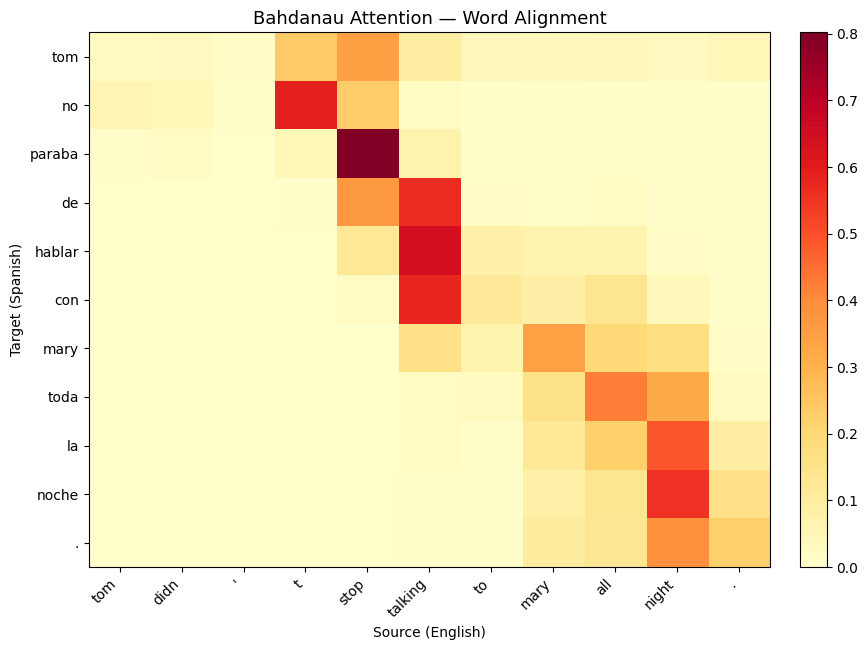

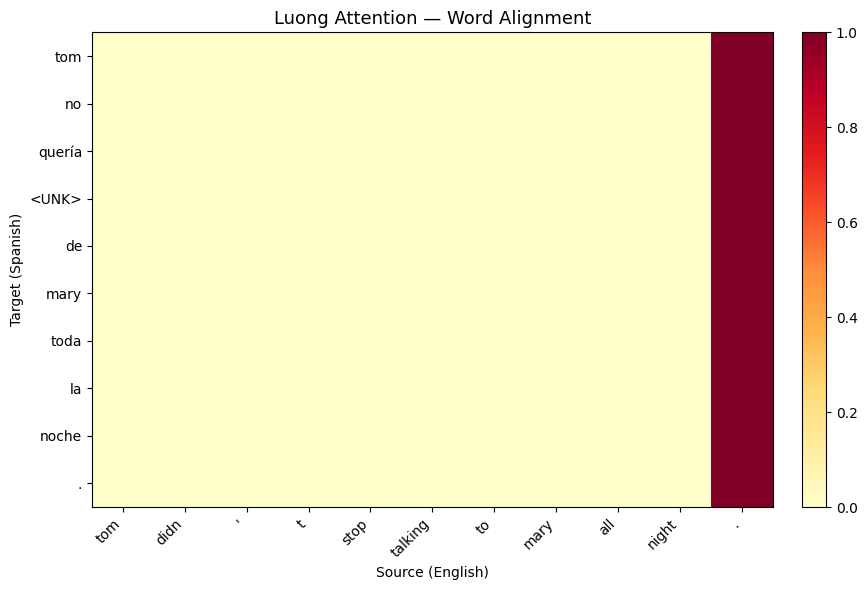

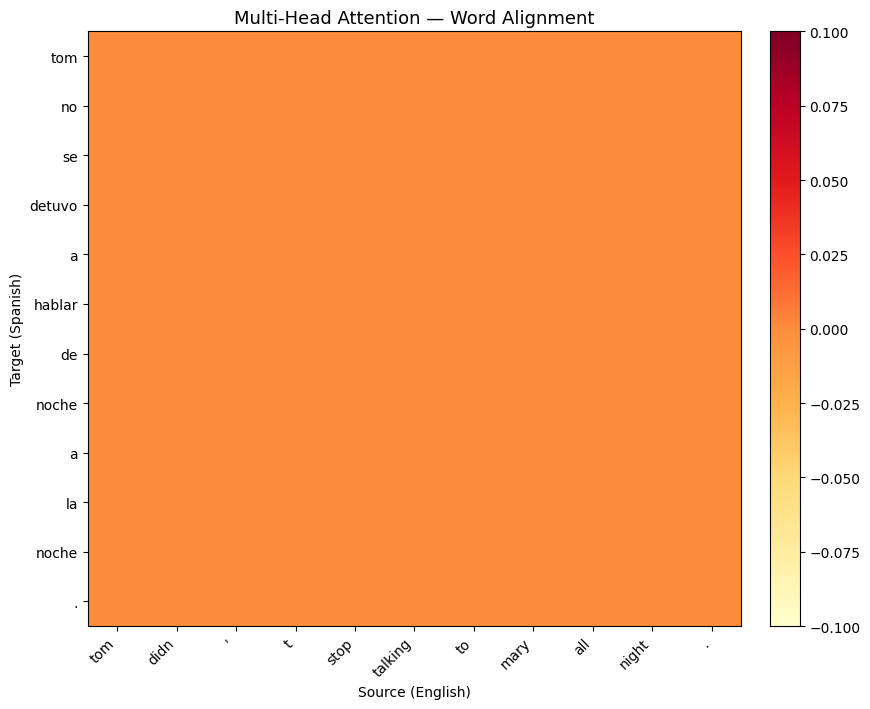


  ATTENTION MECHANISM COMPARISON — PyTorch
  Variant         |  Test BLEU |     Params |   Time (s)
  ----------------+------------+------------+-----------
  No Attention    |     0.2942 | 14,327,060 |      635.6
  Bahdanau        |     0.3803 | 16,686,868 |      874.2
  Luong           |     0.2866 | 16,424,212 |      720.8
  Multi-Head      |     0.2993 | 16,424,212 |     1208.9


In [6]:
# Step 6: Evaluation & Comparison
"""
Final evaluation on the held-out TEST set (never seen during training).
Includes:
  - Test BLEU for all 4 variants
  - Training loss curves (convergence speed comparison)
  - Validation BLEU curves (generalization comparison)
  - Attention heatmaps side-by-side (Bahdanau vs Luong vs Multi-Head)
"""
print("=" * 60)
print("[6/9] EVALUATION & COMPARISON")
print("=" * 60)

# Test BLEU for all 4 models
print("\n  Computing test BLEU for all variants...")

models = {
    'No Attention': model_no_attn,
    'Bahdanau': model_bahdanau,
    'Luong': model_luong,
    'Multi-Head': model_multihead
}

test_bleus = {}
for name, model in models.items():
    bleu = evaluate_bleu(model, test_src, test_tgt)
    test_bleus[name] = bleu
    print(f"    {name:15s} | Test BLEU: {bleu:.4f}")

print(f"\n  {'='*50}")
print(f"  Best: {max(test_bleus, key=test_bleus.get)} ({max(test_bleus.values()):.4f})")

# Training curves
histories = {
    'No Attention': hist_no_attn,
    'Bahdanau': hist_bahdanau,
    'Luong': hist_luong,
    'Multi-Head': hist_multihead
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1 = axes[0]
for name, hist in histories.items():
    ax1.plot(range(1, hist['epochs'] + 1), hist['train_losses'], label=name, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

# BLEU curves
ax2 = axes[1]
for name, hist in histories.items():
    ax2.plot(range(1, hist['epochs'] + 1), hist['val_bleus'], label=name, linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation BLEU')
ax2.set_title('Validation BLEU Over Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: results/training_curves.png")

# Attention heatmaps side-by-side
# Pick a medium-length sentence for readable heatmaps
heatmap_idx = sample_indices[4]  # longest of our samples
heatmap_src_tensor = test_src[heatmap_idx].unsqueeze(0)
src_tokens_viz = decode_tokens(test_src[heatmap_idx].cpu().numpy(), src_idx2word)

def extract_attention_matrix(model, src_tensor, is_luong=False):
    """Extract attention weights from a trained model for one sentence."""
    model.eval()
    with torch.no_grad():
        enc_out, hidden = model.encoder(src_tensor)
        decoder_input = torch.tensor([SOS_IDX], device=device)
        attn_matrix = []
        hyp_tokens = []
        h_tilde = torch.zeros(1, HIDDEN_DIM, device=device) if is_luong else None

        for t in range(1, MAX_LENGTH):
            if is_luong:
                pred, hidden, attn_w, h_tilde = model.decoder.forward_with_attention(
                    decoder_input, hidden, enc_out, h_tilde)
            else:
                pred, hidden, attn_w = model.decoder.forward_with_attention(
                    decoder_input, hidden, enc_out)

            attn_matrix.append(attn_w.squeeze(0).cpu().numpy())
            top1 = pred.argmax(dim=1)
            word = tgt_idx2word.get(str(top1.item()), '<UNK>')
            if word == '<EOS>':
                break
            hyp_tokens.append(word)
            decoder_input = top1

    return np.array(attn_matrix)[:, :len(src_tokens_viz)], hyp_tokens

# Extract for all 3 attention variants
attn_bah, hyp_bah = extract_attention_matrix(model_bahdanau, heatmap_src_tensor)
attn_lu, hyp_lu = extract_attention_matrix(model_luong, heatmap_src_tensor, is_luong=True)
attn_mh, hyp_mh = extract_attention_matrix(model_multihead, heatmap_src_tensor)

# Use Bahdanau's hypothesis as shared y-axis (best BLEU = most reliable)
# Trim all attention matrices to the same target length
shared_tgt = hyp_bah
shared_len = len(shared_tgt)

plot_attention_comparison(
    weights_list=[attn_bah[:shared_len], attn_lu[:shared_len], attn_mh[:shared_len]],
    labels=['Bahdanau (Additive)', 'Luong (General)', 'Multi-Head (8 heads)'],
    src_tokens=src_tokens_viz,
    tgt_tokens=shared_tgt,
    save_path='results/attention_comparison.png'
)

# Individual heatmaps per variant (with their own hypotheses for accuracy)
for name, attn, hyp in [('Bahdanau', attn_bah, hyp_bah),
                         ('Luong', attn_lu, hyp_lu),
                         ('Multi-Head', attn_mh, hyp_mh)]:
    plot_attention_heatmap(
        attn[:len(hyp)], src_tokens_viz, hyp,
        title=f'{name} Attention — Word Alignment',
        save_path=f'results/{name.lower().replace("-", "")}_attention_heatmap.png'
    )

# Summary table
print(f"\n  {'='*60}")
print(f"  ATTENTION MECHANISM COMPARISON — PyTorch")
print(f"  {'='*60}")
print(f"  {'Variant':15s} | {'Test BLEU':>10s} | {'Params':>10s} | {'Time (s)':>10s}")
print(f"  {'-'*15}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")

perfs = {
    'No Attention': perf_no_attn,
    'Bahdanau': perf_bahdanau,
    'Luong': perf_luong,
    'Multi-Head': perf_multihead
}

for name in models:
    bleu = test_bleus[name]
    params = histories[name]['n_params']
    time_s = perfs[name]['time']
    print(f"  {name:15s} | {bleu:10.4f} | {params:>10,} | {time_s:>10.1f}")

[7/9] BLEU BY SENTENCE LENGTH
    No Attention    | len   2-6 | n= 2805 | BLEU: 0.3401
    No Attention    | len   6-7 | n= 2221 | BLEU: 0.3589
    No Attention    | len   7-9 | n= 4427 | BLEU: 0.3293
    No Attention    | len  9-18 | n= 4858 | BLEU: 0.2480

    Bahdanau        | len   2-6 | n= 2805 | BLEU: 0.3865
    Bahdanau        | len   6-7 | n= 2221 | BLEU: 0.4102
    Bahdanau        | len   7-9 | n= 4427 | BLEU: 0.4052
    Bahdanau        | len  9-18 | n= 4858 | BLEU: 0.3570

    Luong           | len   2-6 | n= 2805 | BLEU: 0.3521
    Luong           | len   6-7 | n= 2221 | BLEU: 0.3655
    Luong           | len   7-9 | n= 4427 | BLEU: 0.3207
    Luong           | len  9-18 | n= 4858 | BLEU: 0.2344

    Multi-Head      | len   2-6 | n= 2805 | BLEU: 0.3536
    Multi-Head      | len   6-7 | n= 2221 | BLEU: 0.3669
    Multi-Head      | len   7-9 | n= 4427 | BLEU: 0.3362
    Multi-Head      | len  9-18 | n= 4858 | BLEU: 0.2503



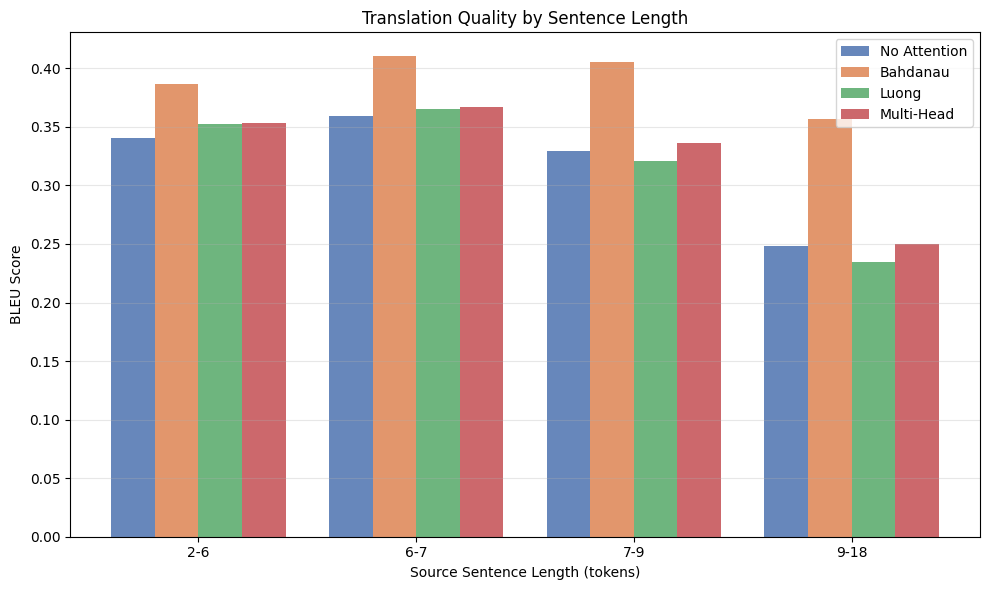

In [7]:
# Step 7: BLEU by Sentence Length
"""
The core argument for attention: fixed-size bottleneck fails
as sentences get longer. This analysis bins test sentences by
source length and computes BLEU per bin, revealing exactly
where no-attention breaks down and attention saves the day.
"""
print("=" * 60)
print("[7/9] BLEU BY SENTENCE LENGTH")
print("=" * 60)

# Compute actual source lengths (exclude padding)
src_lengths = (test_src != PAD_IDX).sum(dim=1).cpu().numpy()

# Re-import since variable name shadowing is possible
from utils.attention_utils import bleu_by_length as compute_bleu_by_length

bleu_length_results = {}
for name, model in models.items():
    all_refs = []
    all_hyps = []
    with torch.no_grad():
        for i in range(0, len(test_src), 256):
            src_batch = test_src[i:i+256]
            tgt_batch = test_tgt[i:i+256]
            translations = greedy_decode(model, src_batch)
            for j in range(len(src_batch)):
                ref = decode_tokens(tgt_batch[j].cpu().numpy(), tgt_idx2word)
                hyp = decode_tokens(translations[j].cpu().numpy(), tgt_idx2word)
                all_refs.append([ref])
                all_hyps.append(hyp)

    bleu_length_results[name] = compute_bleu_by_length(
        all_refs, all_hyps, src_lengths, n_buckets=4)

    buckets = bleu_length_results[name]
    for lbl, score, cnt in zip(buckets['bucket_labels'],
                                buckets['bleu_scores'],
                                buckets['counts']):
        print(f"    {name:15s} | len {lbl:>5s} | n={cnt:>5} | BLEU: {score:.4f}")
    print()

plot_bleu_by_length(bleu_length_results, save_path='results/bleu_by_length.png')

In [8]:
# Step 8: Performance Benchmarks
"""
Inference speed and model size comparison.
Important for deployment decisions — attention adds quality
but also computational cost per token (quadratic in sequence length
for multi-head, linear for single-head variants).
"""
print("=" * 60)
print("[8/9] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Inference benchmarks — time to translate the full test set
print("\n  Inference speed (full test set):")
print(f"  {'-'*55}")

inference_results = {}
for name, model in models.items():
    result = track_inference(
        predict_fn=lambda x, m=model: greedy_decode(m, x),
        X=test_src,
        n_runs=3
    )
    inference_results[name] = result
    print(f"    {name:15s} | {result['total_time']:.2f}s avg | "
          f"{result['per_sample_us']:.0f} µs/sentence | "
          f"{result['samples_per_sec']:.0f} sent/s")

# Model sizes
print(f"\n  Model sizes:")
print(f"  {'-'*55}")
for name, model in models.items():
    size_mb = get_model_size(model)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"    {name:15s} | {n_params:>12,} params | {size_mb:.1f} MB")

# Training summary
print(f"\n  Training summary:")
print(f"  {'-'*55}")
for name in models:
    hist = histories[name]
    perf = perfs[name]
    print(f"    {name:15s} | {hist['epochs']:>2} epochs | "
          f"{perf['time']:.0f}s | GPU: {perf['gpu_memory']:.0f} MB")

[8/9] PERFORMANCE BENCHMARKS

  Inference speed (full test set):
  -------------------------------------------------------
    No Attention    | 0.01s avg | 1 µs/sentence | 1879449 sent/s
    Bahdanau        | 0.67s avg | 47 µs/sentence | 21390 sent/s
    Luong           | 0.45s avg | 31 µs/sentence | 31920 sent/s
    Multi-Head      | 0.59s avg | 41 µs/sentence | 24182 sent/s

  Model sizes:
  -------------------------------------------------------
    No Attention    |   14,327,060 params | 0.0 MB
    Bahdanau        |   16,686,868 params | 0.0 MB
    Luong           |   16,424,212 params | 0.0 MB
    Multi-Head      |   16,424,212 params | 0.0 MB

  Training summary:
  -------------------------------------------------------
    No Attention    | 13 epochs | 636s | GPU: 475 MB
    Bahdanau        | 13 epochs | 874s | GPU: 874 MB
    Luong           | 11 epochs | 721s | GPU: 1015 MB
    Multi-Head      | 15 epochs | 1209s | GPU: 1295 MB


In [9]:
# Step 9: Save Results
"""
Save the best variant (Bahdanau) for cross-framework comparison.
Only the winner gets saved — TF pipeline will produce its own metrics.json,
then we compare the two to pick the MLflow/deployment candidate.
"""
print("=" * 60)
print("[9/9] SAVE RESULTS")
print("=" * 60)

# Save model checkpoint
best_name = max(test_bleus, key=test_bleus.get)
best_model = models[best_name]
best_hist = histories[best_name]
best_perf = perfs[best_name]
best_inf = inference_results[best_name]

torch.save(best_model.state_dict(), 'results/best_model_state.pt')
print(f"\n  Best variant: {best_name}")
print(f"  Saved: results/best_model_state.pt")

# Build results dict (manual — translation has no evaluate_classifier output)
results = {
    'framework': 'PyTorch',
    'model': 'Attention (Seq2Seq)',
    'test_bleu': float(test_bleus[best_name]),
    'training_time': float(best_perf['time']),
    'inference_time_per_sample_us': float(best_inf['per_sample_us']),
    'model_size_bytes': int(os.path.getsize('results/best_model_state.pt')),
    'peak_memory_mb': float(best_perf['gpu_memory']),
    'n_params': int(best_hist['n_params']),
    'epochs': best_hist['epochs'],
    'best_val_bleu': float(best_hist['best_bleu']),
    'best_variant': best_name,
    'attention_type': 'Bahdanau (Additive)',
    'encoder': 'Bidirectional GRU',
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'teacher_forcing_ratio': TEACHER_FORCING_RATIO
}

# Save to local results/
save_results(results, save_dir='results')

# Save to shared cross-framework comparison
add_result('attention', results)

# Print cross-framework comparison table
print_comparison('attention')

[9/9] SAVE RESULTS

  Best variant: Bahdanau
  Saved: results/best_model_state.pt
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\attention.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: ATTENTION
Metric                                    TensorFlow               PyTorch
--------------------------------------------------------------------------
model                           Attention (Bahdanau)   Attention (Seq2Seq)
test_bleu                                     0.3368                0.3803
best_val_bleu                                 0.3353                0.3836
n_params                                    16682260              16686868
training_time                              278.2 min              14.6 min
epochs                                            30                    13
inference_time_per_sample_us               398.61 µs              46.75 µs
model_size_byte

In [10]:
# Step 10: MLflow Tracking + Model Export
"""
Deployment staging for PyTorch Bahdanau attention — best attention framework.
PT Bahdanau: BLEU 0.3803, 16.2 min training, 21.59 µs/sentence.
TF Bahdanau: BLEU 0.3368, 278 min training, 398.61 µs/sentence.
"""

import mlflow
import mlflow.pytorch
from mlflow.models import infer_signature

print("=" * 60)
print("[10/10] MLflow Tracking + Model Export")
print("=" * 60)

mlflow.set_experiment("attention")

with mlflow.start_run(run_name="pytorch-bahdanau-en-es"):
    # Log hyperparameters
    mlflow.log_params({
        'architecture': 'Seq2Seq + Bahdanau Additive Attention',
        'dataset': 'Tatoeba EN→ES (114K train, word-level)',
        'encoder': 'Bidirectional GRU(256→512) + Linear(1024→512)',
        'decoder': 'GRU([embed;context_1024], 512) + FC(vocab)',
        'attention': 'V·tanh(W1·s + W2·h) — additive scoring',
        'n_params': int(best_hist['n_params']),
        'src_vocab_size': SRC_VOCAB_SIZE,
        'tgt_vocab_size': TGT_VOCAB_SIZE,
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'teacher_forcing_ratio': TEACHER_FORCING_RATIO,
        'epochs': best_hist['epochs'],
        'max_length': MAX_LENGTH,
        'gradient_clip': 1.0,
    })

    # Log metrics
    mlflow.log_metrics({
        'test_bleu': float(test_bleus[best_name]),
        'val_bleu': float(best_hist['best_bleu']),
        'training_time_s': float(best_perf['time']),
        'inference_us_per_sample': float(best_inf['per_sample_us']),
        'gpu_peak_memory_mb': float(best_perf['gpu_memory']),
    })

    # Log model — seq2seq has encoder + decoder, save as combined state dict
    # MLflow logs the full model object; we use encoder for signature demo
    best_model.eval()
    best_model_cpu = best_model.cpu()

    sample_src = torch.randint(0, SRC_VOCAB_SIZE, (1, MAX_LENGTH))
    with torch.no_grad():
        sample_enc_out, sample_hidden = best_model_cpu.encoder(sample_src)
    signature = infer_signature(
        sample_src.numpy(),
        sample_enc_out.numpy()
    )
    mlflow.pytorch.log_model(
        best_model_cpu, name="attention-bahdanau-en-es", signature=signature
    )

    # Log artifacts
    mlflow.log_artifact('results/best_model_state.pt')
    mlflow.log_artifact('results/training_curves.png')
    mlflow.log_artifact('results/attention_comparison.png')
    mlflow.log_artifact('results/bleu_by_length.png')
    mlflow.log_artifact('results/bahdanau_attention_heatmap.png')

    run_id = mlflow.active_run().info.run_id

# Move model back to GPU
best_model.to(device)
best_model.train()

print(f"\n  Experiment: attention")
print(f"  Run ID: {run_id}")
print(f"  Model: attention-bahdanau-en-es (PyTorch)")
print(f"  Test BLEU: {test_bleus[best_name]:.4f}")
print(f"\n  Artifacts logged:")
print(f"    - attention-bahdanau-en-es (MLflow model)")
print(f"    - best_model_state.pt")
print(f"    - training_curves.png")
print(f"    - attention_comparison.png")
print(f"    - bleu_by_length.png")
print(f"    - bahdanau_attention_heatmap.png")
print(f"\nMLflow tracking complete — Bahdanau staged for deployment.")

[10/10] MLflow Tracking + Model Export


2026/04/06 21:53:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/06 21:53:38 INFO mlflow.store.db.utils: Updating database tables
2026/04/06 21:53:39 INFO mlflow.tracking.fluent: Experiment with name 'attention' does not exist. Creating a new experiment.
2026/04/06 21:53:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/06 21:53:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, pl


  Experiment: attention
  Run ID: c081d5425443416685c17a52b154e1cb
  Model: attention-bahdanau-en-es (PyTorch)
  Test BLEU: 0.3803

  Artifacts logged:
    - attention-bahdanau-en-es (MLflow model)
    - best_model_state.pt
    - training_curves.png
    - attention_comparison.png
    - bleu_by_length.png
    - bahdanau_attention_heatmap.png

MLflow tracking complete — Bahdanau staged for deployment.
